# ETL, Plots and Storytelling Project. PART 1

For this projet, we will work with real-world data and engage our audience (business stakeholders and decision-makers) through a range of visualizations and reports.

The project is structured into five sections:

Section 1 – Sales Trend Over Time. \
Section 2 – Grouping and Aggregation. \
Section 3 – Payment Analysis. \
Section 4 – Customer Satisfaction Level. \
Section 5 – Marketing Analytics Metrics. 

This is an extensive project, involving a large number of analyses in Python. The visualizations depend on the data, so we will preprocess and adjust the data before creating each chart. For each section, we will address multiple business questions using visualizations and storytelling.

This is a project made of 3 parts, this is the first one. 

Loading Libraries

In [1]:
# Imports

import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
import warnings
warnings.filterwarnings('ignore')

Loading and understanding data

In [2]:
# Loading dataset

FILE_ID = "1ikA5f7Y6ccuy1pPlR6kV569p4xtQoo05"

url = f"https://drive.google.com/uc?id={FILE_ID}"

df = pd.read_csv(url)

In [3]:
# Data shape

df.shape

(116581, 53)

In [4]:
# Data sample

df.sample(10)

,order_id,order_id3,customer_id3,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,seller_city,seller_state,product_category_name_english,review_response_time,order_purchase_year,order_purchase_month,order_purchase_dayofweek,order_purchase_hour,order_purchase_day,order_purchase_mon
109110,ON56946,11644b89c9bd9d27b1c1fda5307844d1,947d490e87464fc7f56c57d24b98564e,delivered,2017-06-08 16:15:15,2017-06-08 22:31:35,2017-06-13 09:46:46,2017-06-23 11:52:09,2017-07-03 00:00:00,2.0,...,Mage,RJ,musical instruments,15.0,2017,6,3,16,Thu,Jun
25092,ON45706,51248b88b0b4821b2e8eb524d990140e,1765717276473594d6231f90c621ea9d,delivered,2018-03-20 14:32:28,2018-03-21 02:55:59,2018-03-22 22:51:28,2018-03-24 01:22:37,2018-04-02 00:00:00,2.0,...,Sao Paulo,SP,toys,3.0,2018,3,1,14,Tue,Mar
91368,ON04296,257a0d5445d4ae131816384009fbb954,067ddd62f5d7b69af563df60ee698b5a,delivered,2018-07-25 10:24:29,2018-07-25 10:35:20,2018-08-01 16:08:00,2018-08-07 00:41:31,2018-08-14 00:00:00,1.0,...,Curitiba,PR,garden tools,0.0,2018,7,2,10,Wed,Jul
62867,ON26419,858c1ff3f8bfa2eb4fc6b27be041ed8c,7a42e67e3638cc187cd614a3590a81b4,delivered,2018-01-03 10:04:31,2018-01-05 02:35:33,2018-01-13 01:58:28,2018-01-17 15:06:49,2018-01-29 00:00:00,1.0,...,Sao Goncalo,RJ,watches gifts,1.0,2018,1,2,10,Wed,Jan
64333,ON52597,885a4bc7ab1c81c53d7ea58b81bb90ef,607564faf101428f9bb69ffe578dff50,delivered,2018-08-04 15:55:29,2018-08-04 16:10:19,2018-08-06 13:19:00,2018-08-13 21:38:53,2018-08-21 00:00:00,1.0,...,Sao Paulo,SP,watches gifts,1.0,2018,8,5,15,Sat,Aug
113205,ON80497,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42,2018-07-31 00:00:00,1.0,...,Guarulhos,SP,industry commerce and business,3.0,2018,7,6,22,Sun,Jul
53141,ON20794,c40ece9c7721bdfa00fd606bbe7b8464,f889f85e7338927a1a51de65484911f1,delivered,2018-07-02 12:09:02,2018-07-02 12:29:59,2018-07-04 13:00:00,2018-07-10 20:39:42,2018-07-23 00:00:00,1.0,...,Sao Paulo,SP,construction tools construction,1.0,2018,7,0,12,Mon,Jul
10971,ON28621,2eb9acb468887e2f0e93b35344bd3656,430fee0b7c8355183a7118a7e413165c,delivered,2018-02-05 17:10:10,2018-02-05 17:32:52,2018-02-09 20:09:40,2018-02-20 22:03:55,2018-03-08 00:00:00,1.0,...,Campo Mourao,PR,cool stuff,1.0,2018,2,0,17,Mon,Feb
13982,ON43077,44a4b28fae9dd152c7102f54dcd723b9,041e732946d597aa439b595a2def33f3,delivered,2018-05-29 14:36:50,2018-05-29 14:52:27,2018-05-30 13:46:00,2018-06-15 18:12:58,2018-08-06 00:00:00,1.0,...,Recife,PE,cool stuff,3.0,2018,5,1,14,Tue,May
88311,ON12173,d5e27d7291d4571c883c69143b590fd5,1bde7825953734db2df2dd6a27cfec02,delivered,2017-11-26 22:49:05,2017-11-27 10:55:17,2017-11-30 16:15:48,2017-12-16 12:36:35,2017-12-20 00:00:00,1.0,...,Sao Jose Do Rio Preto,SP,garden tools,0.0,2017,11,6,22,Sun,Nov


In [5]:
# Columns names

df.columns

Index(['order_id', 'order_id3', 'customer_id3', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id3',
       'seller_id3', 'shipping_limit_date', 'price', 'freight_value',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_id3', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'product_id',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_id', 'customer_unique_id', 'customer_uniqueid3',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'seller_id', 'seller_zip_code_prefix', 'seller_city', '

Customized functions to data visualization

You can always create python functions to personalize or customize your charts

In [6]:
# Function to format the plot's axes (ax) with right border option

def format_spines(ax, right_border = True):
    
    # Set the bottom spine color
    ax.spines['bottom'].set_color('#000000')  
    
    # Set the left spine color
    ax.spines['left'].set_color('#000000')  
    
    # Hide the top spine for a cleaner look
    ax.spines['top'].set_visible(False)   
    
    # Check whether the right spine should be displayed
    if right_border:       
        
        # If True, set the right spine color to white
        ax.spines['right'].set_color('#FFFFFF')  
        
    else:
        
        # If False, also set the right spine color to white (hidden effect)
        ax.spines['right'].set_color('#FFFFFF') 
    
    # Set the plot background color to white
    ax.patch.set_facecolor('#FFFFFF')    

In [7]:
# Define a function to create a count plot

def count_plot(feature, df, colors = 'Greens_r', hue = False, ax = None, title = ''):
    
    # Store the total number of observations in the dataset
    ncount = len(df)
    
    # Create the count plot, optionally grouped by a categorical variable (hue)
    if hue != False:
        ax = sns.countplot(x = feature, data = df, palette = colors, hue = hue, ax = ax)
    else:
        ax = sns.countplot(x = feature, data = df, palette = colors, ax = ax)
        
    # Apply custom spine formatting for improved visualization aesthetics
    format_spines(ax)

    # Compute and annotate the percentage for each bar in the plot
    for p in ax.patches:
        
        # Extract x-coordinates of the bar
        x = p.get_bbox().get_points()[:,0] 
        
        # Extract the height (top y-coordinate) of the bar
        y = p.get_bbox().get_points()[1,1] 
        
        # Annotate percentage above each bar
        ax.annotate('{:.1f}%'.format(100. * y / ncount), (x.mean(), y), ha = 'center', va = 'bottom') 
    
    # Set the plot title depending on whether a grouping variable is used
    if not hue:
        
        # Without grouping variable
        ax.set_title(df[feature].describe().name + ' Analysis', size = 13, pad = 15) 
        
    else:
        
        # With grouping variable
        ax.set_title(df[feature].describe().name + ' Analysis by ' + hue, size = 13, pad = 15) 
    
    # Override with a custom title if provided
    if title != '':
        ax.set_title(title)  
    
    # Adjust layout to prevent overlapping elements
    plt.tight_layout()

In [8]:
# Define a function to create a bar plot

def bar_plot(x, y, df, colors = 'Greens_r', hue = False, ax = None, value = False, title = ''):
    
    # Attempt to compute the total of y; fallback to x if it fails
    try:
        
        # Compute the total sum of the y variable
        ncount = sum(df[y]) 
        
    except:
        
        # Fallback: compute the total sum of the x variable
        ncount = sum(df[x]) 

    # Create the bar plot, optionally grouped by a categorical variable (hue)
    if hue != False:
        
        # With grouping variable
        ax = sns.barplot(x = x, y = y, data = df, palette = colors, hue = hue, ax = ax, ci = None) 
        
    else:
        
        # Without grouping variable
        ax = sns.barplot(x = x, y = y, data = df, palette = colors, ax = ax, ci = None) 

    # Apply custom spine formatting for improved visualization aesthetics
    format_spines(ax)

    # Annotate each bar with either absolute values or percentages
    for p in ax.patches:
        
        # Extract x-coordinates of the bar
        xp = p.get_bbox().get_points()[:,0] 
        
        # Extract the height (top y-coordinate) of the bar
        yp = p.get_bbox().get_points()[1,1] 
        
        # If value=True, display absolute values (in thousands)
        if value:
            
            ax.annotate('{:.2f}k'.format(yp / 1000), (xp.mean(), yp), ha = 'center', va = 'bottom') 
            
        else:
            
            # Otherwise, display percentages
            ax.annotate('{:.1f}%'.format(100. * yp / ncount), (xp.mean(), yp), ha = 'center', va = 'bottom') 
            
    # Set the plot title depending on whether a grouping variable is used
    if not hue:
        
        # Without grouping variable
        ax.set_title(df[x].describe().name + ' Analysis', size = 12, pad = 15) 
        
    else:
        
        # With grouping variable
        ax.set_title(df[x].describe().name + ' Analysis by ' + hue, size = 12, pad = 15) 
    
    # Override with a custom title if provided
    if title != '':
        
        ax.set_title(title) 
    
    # Adjust layout to prevent overlapping elements
    plt.tight_layout()

## Section 1 - Sales Trend Over Time

### Question 1.1 – How Did Sales Perform by Year (in Percentage Terms)? 


In [9]:
# Checking the total values per year

df.order_purchase_year.value_counts()

order_purchase_year
2018    63199
2017    52994
2016      388
Name: count, dtype: int64

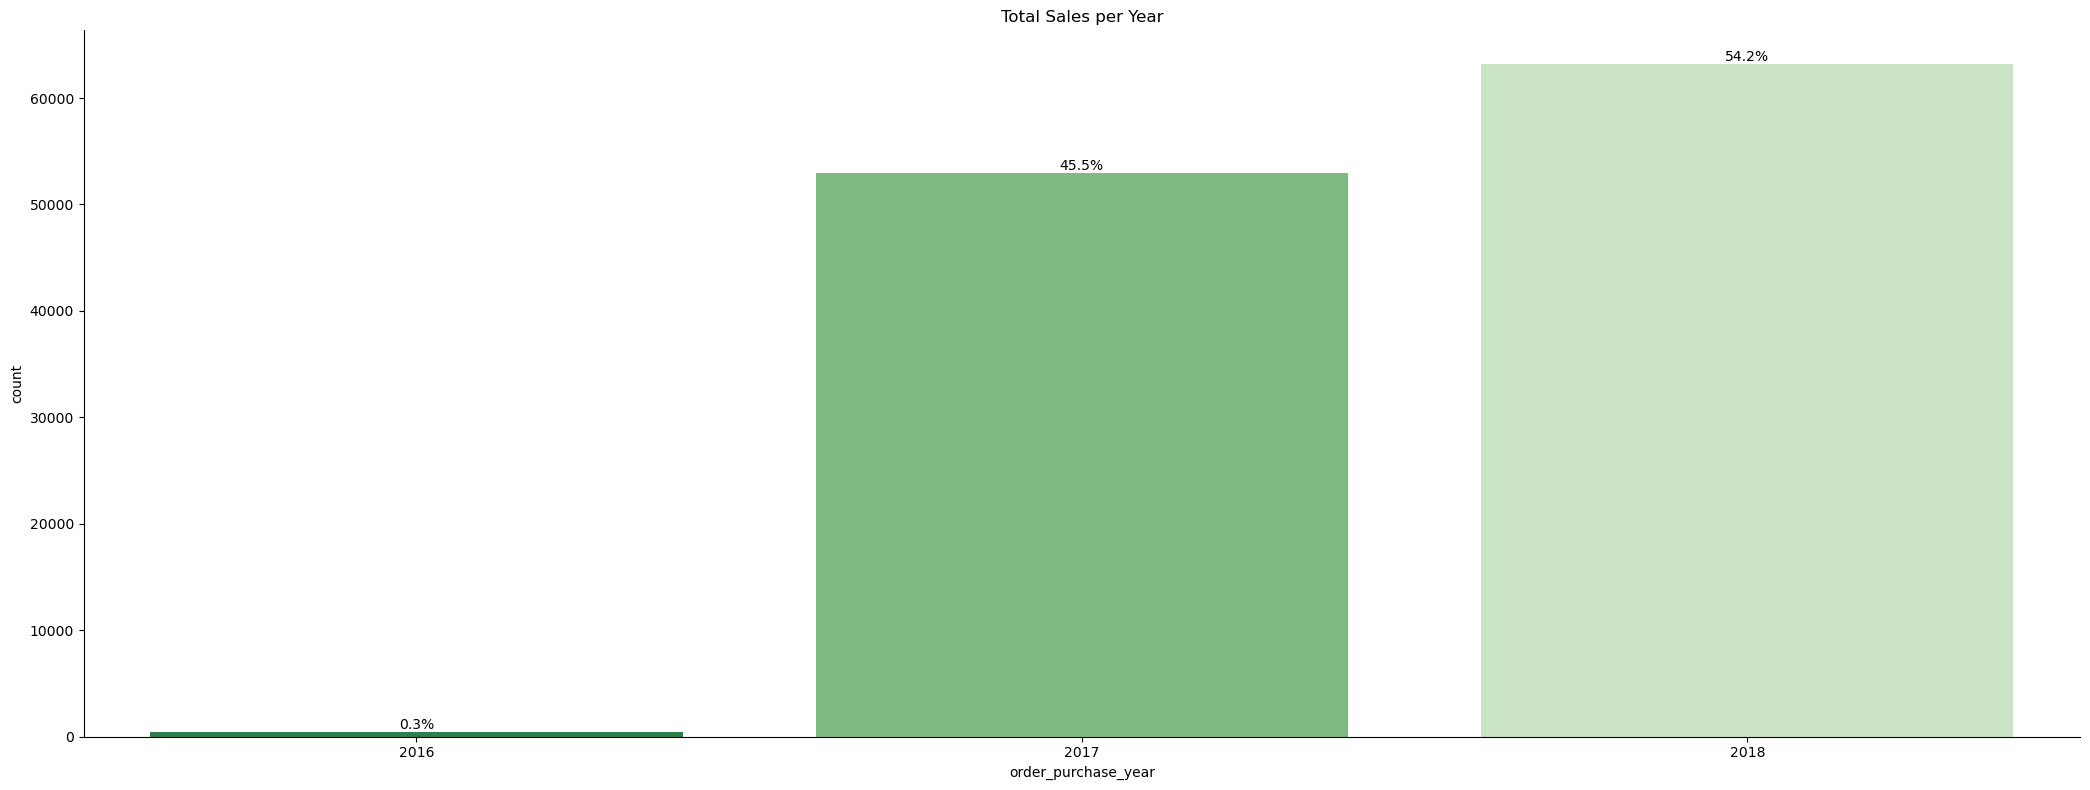

In [11]:
# Total Sales per Year

fig, axs = plt.subplots(1, 1, figsize = (21, 8))
count_plot(feature = 'order_purchase_year', 
               df = df, 
               ax = axs, 
               title = 'Total Sales per Year')
plt.show();

### Question 1.2 -  How Did Monthly Sales Perform Across Each Year (in Percentage Terms) ?

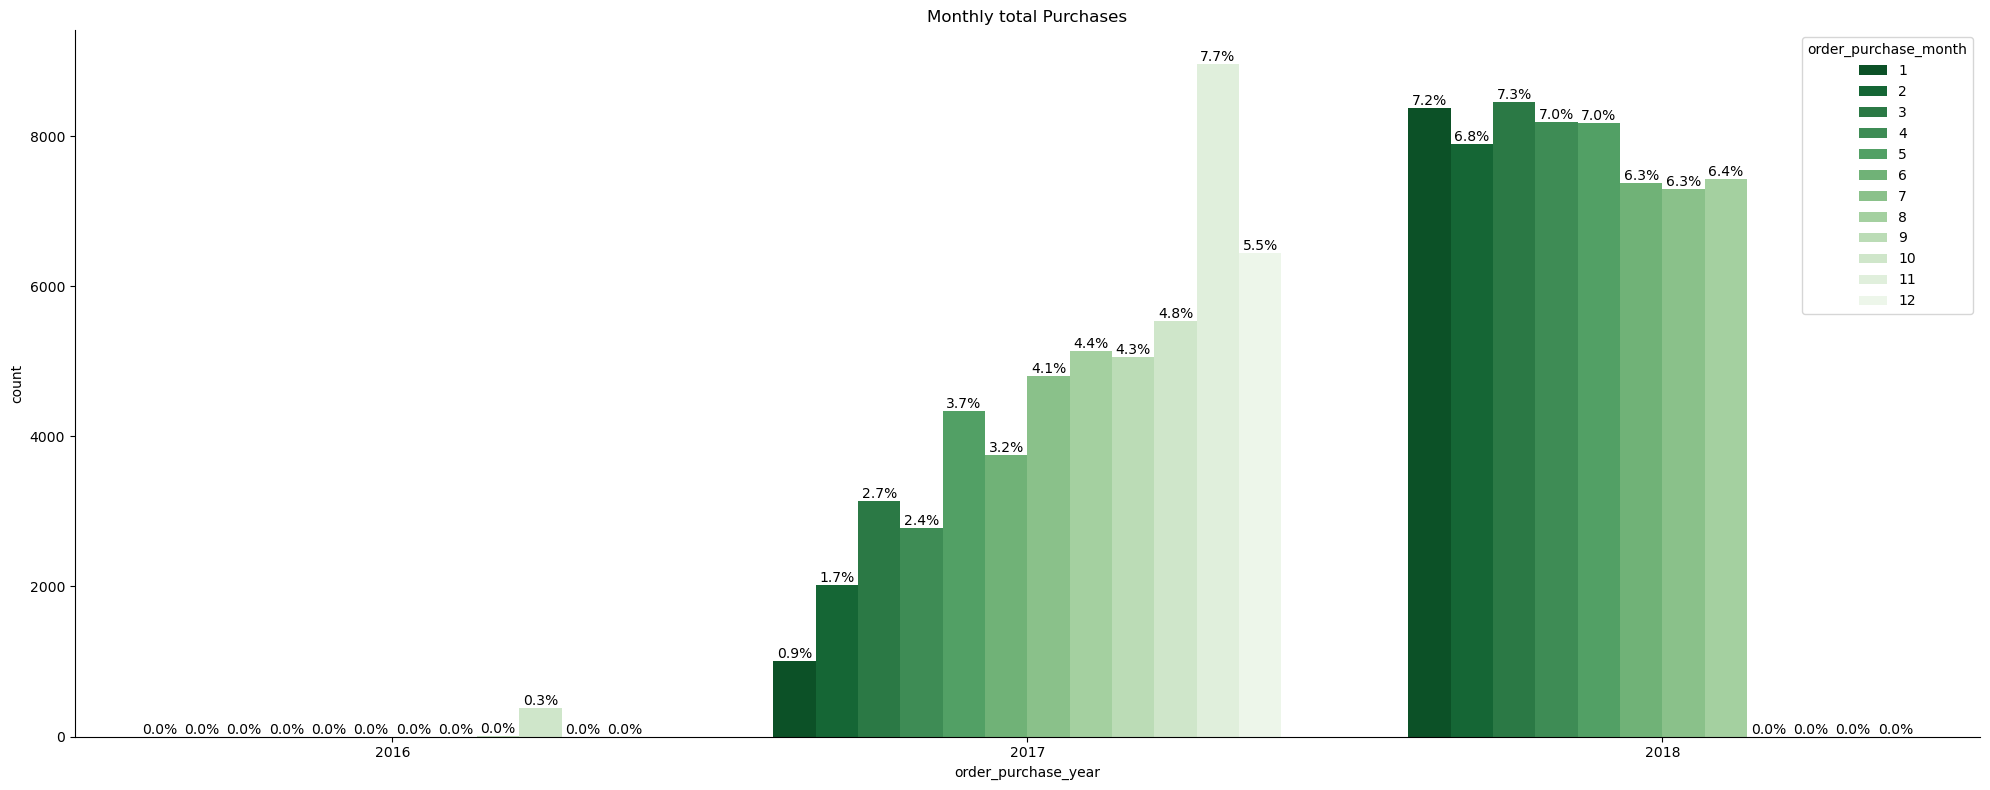

In [12]:
# Monthly total Purchases per year

fig, axs = plt.subplots(1, 1, figsize = (20, 8))
count_plot(feature = 'order_purchase_year', 
               df = df, 
               ax = axs, 
               hue = 'order_purchase_month', 
               title = 'Monthly total Purchases')
plt.show();

### Question 1.3 -  How did Sales Perform by day of week each year (in Percentagem Terms) ? 

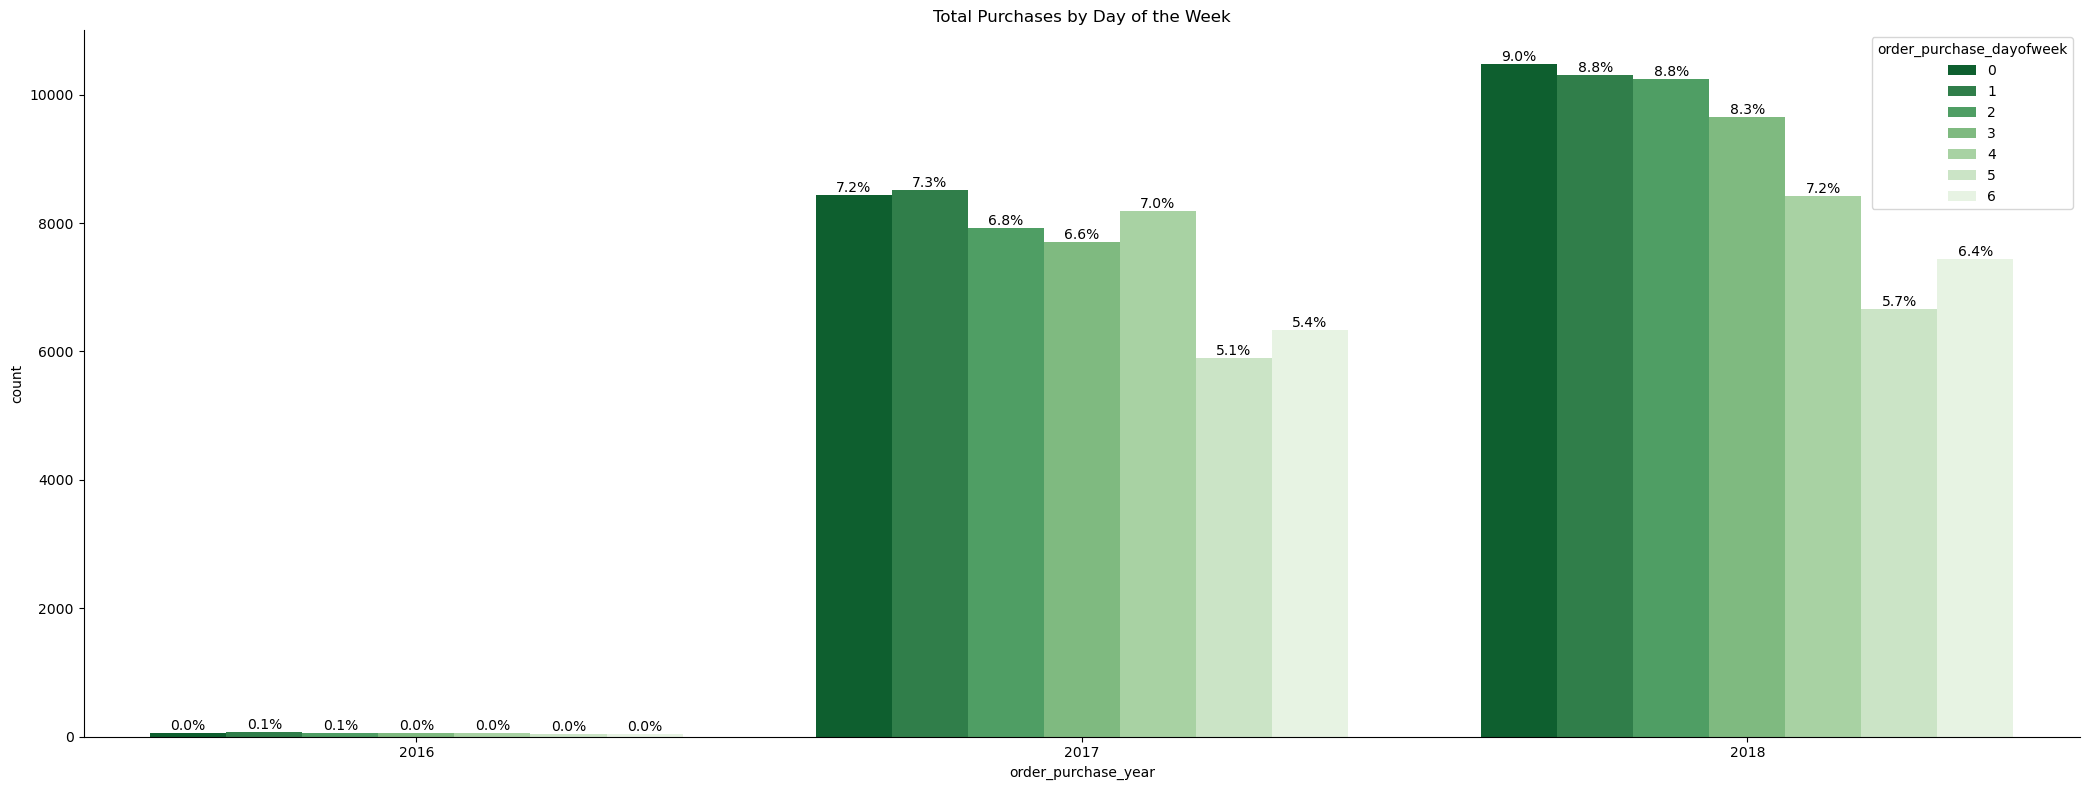

In [14]:
# Total Purchases by Day of the Week for Each Year

fig, axs = plt.subplots(1, 1, figsize = (21, 8))
count_plot(feature = 'order_purchase_year', 
               df = df, 
               ax = axs, 
               hue = 'order_purchase_dayofweek', 
               title = 'Total Purchases by Day of the Week')
plt.show();

### Question 1.4 - Answer 1.2 Question in Absolute Terms


In [15]:
# Grouping by yearly and monthly sells

df_ytsales = df.groupby(['order_purchase_year', 'order_purchase_month'], 
                        as_index = False).sum().loc[:, ['order_purchase_year', 
                                                        'order_purchase_month', 
                                                        'payment_value']]

In [16]:
# Preparing the dataframes

df_s2016 = df_ytsales[df_ytsales['order_purchase_year']==2016]
df_s2017 = df_ytsales[df_ytsales['order_purchase_year']==2017]
df_s2018 = df_ytsales[df_ytsales['order_purchase_year']==2018]

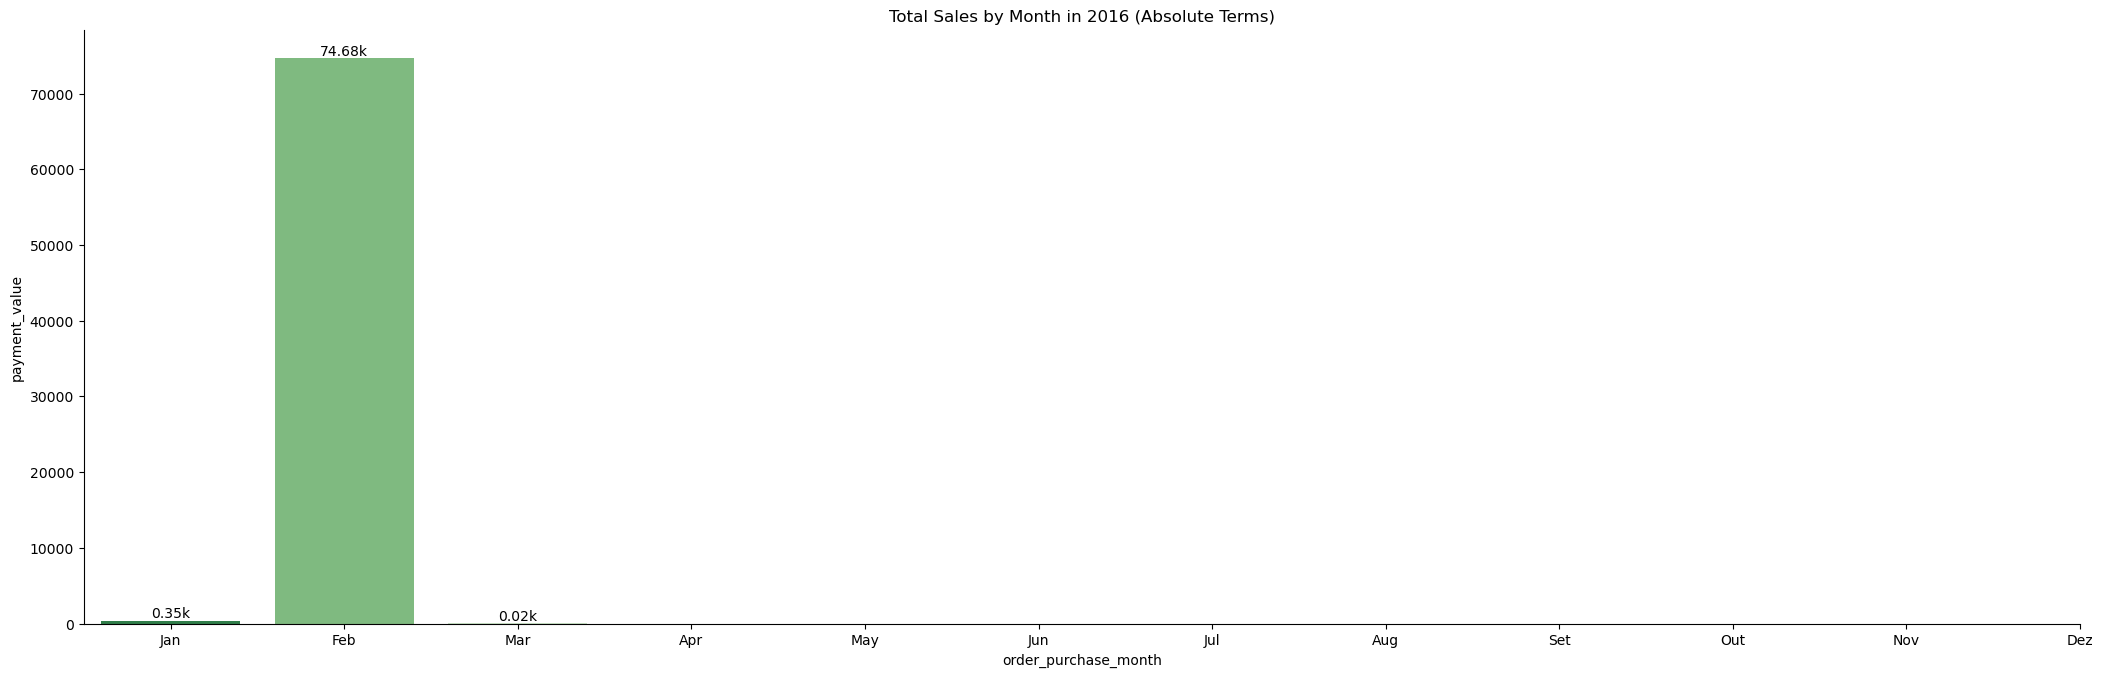

In [17]:
# Total Sales by Month in 2016 (Absolute Terms)

fig, axs = plt.subplots(1, 1, figsize = (21, 7))
bar_plot(x = 'order_purchase_month', y = 'payment_value', df = df_s2016, ax = axs, value = True)
axs.set_title('Total Sales by Month in 2016 (Absolute Terms)')
plt.xticks(np.arange(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Set', 'Out', 'Nov', 'Dez'])
plt.show()

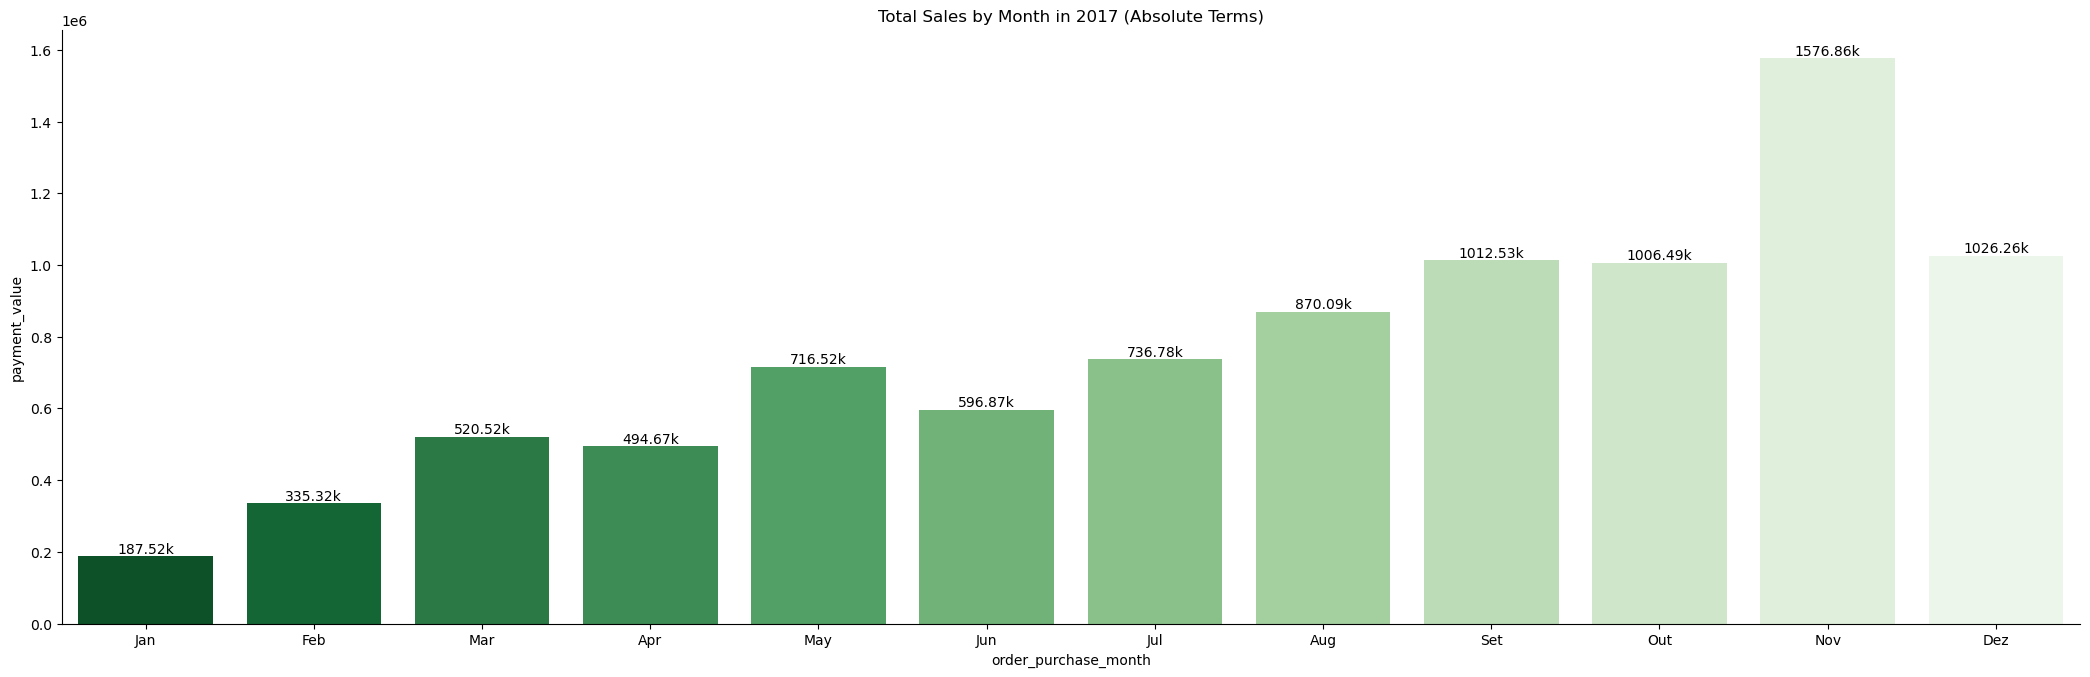

In [25]:
# Total Sales by Month in 2017 (Absolute Terms)

fig, axs = plt.subplots(1, 1, figsize = (21, 7))
bar_plot(x = 'order_purchase_month', y = 'payment_value', df = df_s2017, ax = axs, value = True)
axs.set_title('Total Sales by Month in 2017 (Absolute Terms)')
plt.xticks(np.arange(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Set', 'Out', 'Nov', 'Dez'])
plt.show()

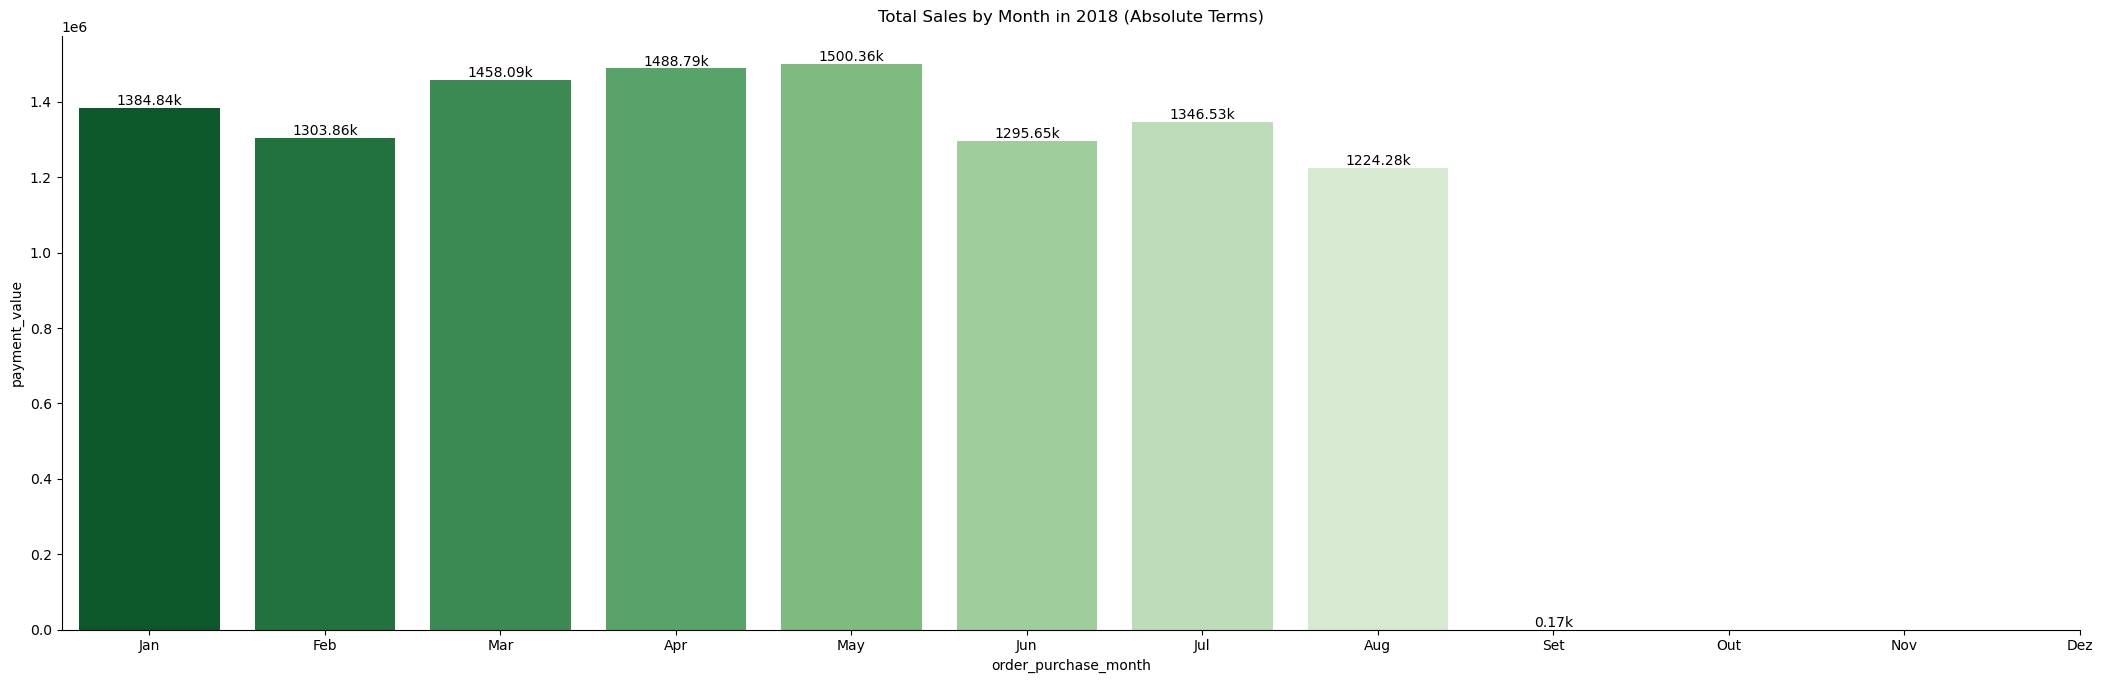

In [26]:
# Total Sales by Month in 2018 (Absolute Terms)

fig, axs = plt.subplots(1, 1, figsize = (21, 7))
bar_plot(x = 'order_purchase_month', y = 'payment_value', df = df_s2018, ax = axs, value = True)
axs.set_title('Total Sales by Month in 2018 (Absolute Terms)', pad = 10)
plt.xticks(np.arange(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Set', 'Out', 'Nov', 'Dez'])
plt.show()

### Question 1.5 – Show the Timeline of Sales Performance Evolution

In [20]:
# Convert the month attribute to ensure correct ordering

df_ytsales['order_purchase_month'] = df_ytsales['order_purchase_month'].astype(str).apply(lambda x: '0' + x if len(x) == 1 else x)

In [21]:
# Creating noew column month_year

df_ytsales['month_year'] = df_ytsales['order_purchase_year'].astype(str) + '-' + df_ytsales['order_purchase_month'].astype(str)
df_ytsales['order_purchase_month'] = df_ytsales['order_purchase_month'].astype(int)

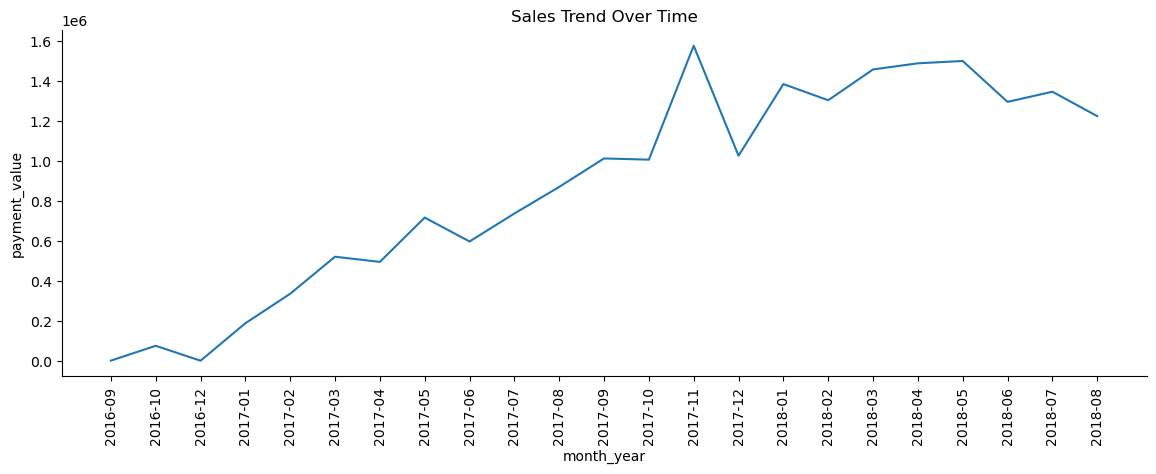

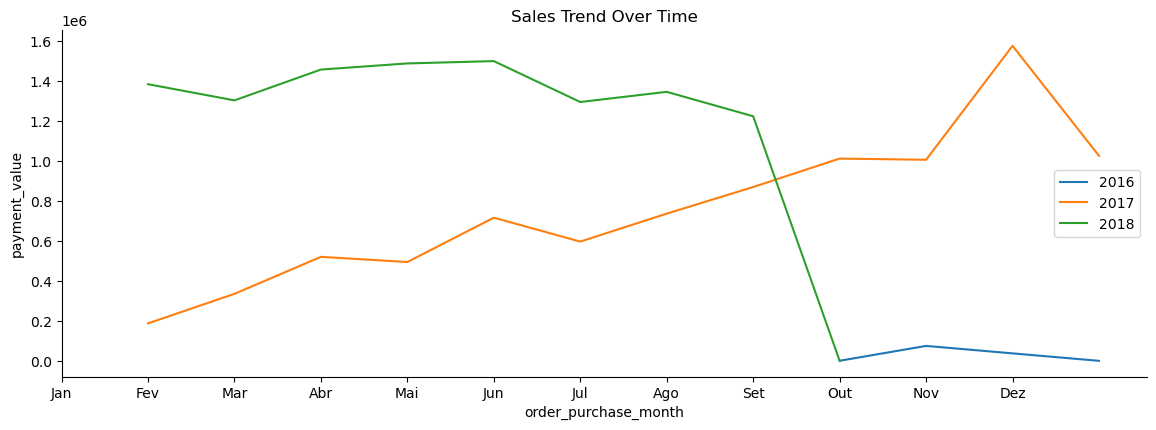

In [22]:
# Sales Trend Over Time

# 1st Plot
fig, ax = plt.subplots(figsize = (14, 4.5))
ax = sns.lineplot(x = 'month_year', y = 'payment_value', data = df_ytsales.iloc[:-1, :])
format_spines(ax, right_border = False)
ax.tick_params(axis = 'x', labelrotation = 90)
ax.set_title('Sales Trend Over Time')
plt.show()

# 2nd Plot
fig, ax = plt.subplots(figsize = (14, 4.5))
ax = sns.lineplot(x = 'order_purchase_month', y = 'payment_value', data = df_s2016, label = '2016')
ax = sns.lineplot(x = 'order_purchase_month', y = 'payment_value', data = df_s2017, label = '2017')
ax = sns.lineplot(x = 'order_purchase_month', y = 'payment_value', data = df_s2018, label = '2018')
format_spines(ax, right_border = False)
ax.set_title('Sales Trend Over Time')
plt.xticks(np.arange(12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.show()

### Question 1.6 – Customer Purchase Behavior Matrix by Hour of the Day

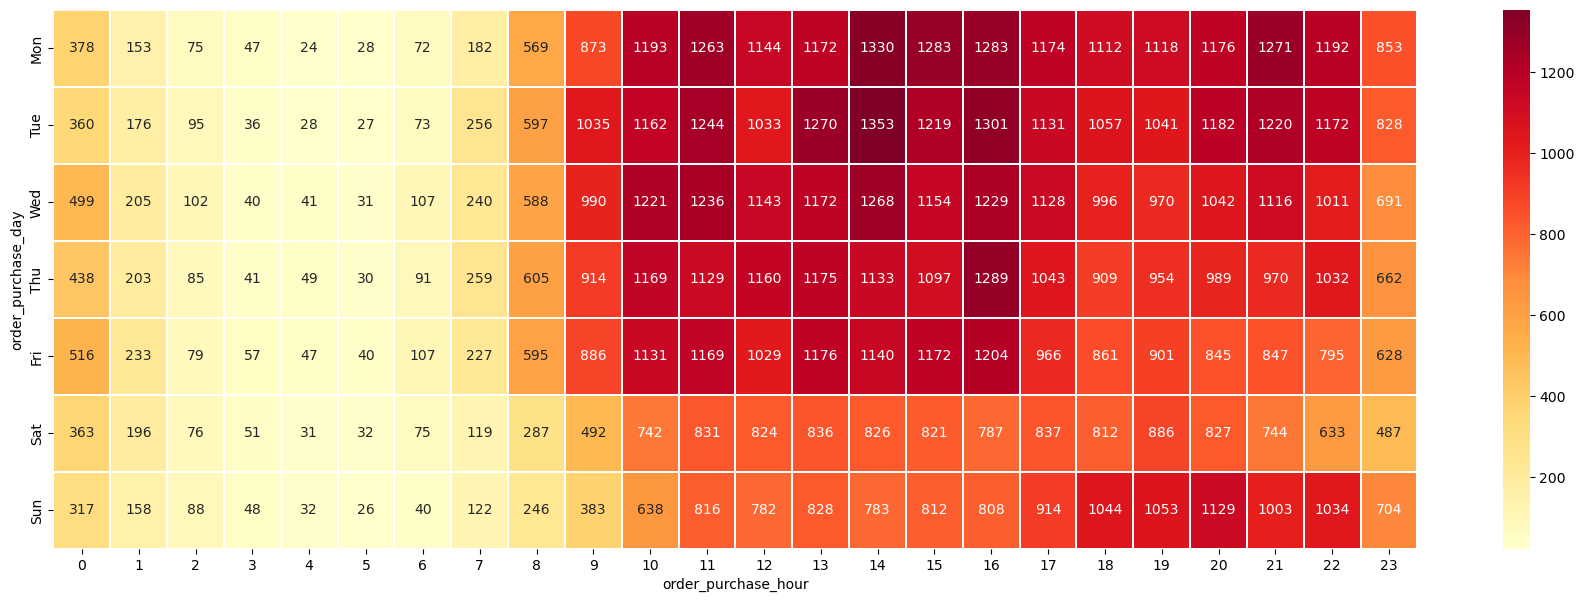

In [23]:
# Costumer Behavier

purchase_count = df.groupby(['order_purchase_day', 'order_purchase_hour']).count()['price'].unstack()
plt.figure(figsize = (22,7))
sns.heatmap(purchase_count.reindex(index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']), 
            cmap = "YlOrRd", 
            annot = True, 
            fmt = "d", 
            linewidths = 0.2)
plt.show()

## We are going to continue in the next part, script dataviz2